In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('./GAM_data.csv')
df

,Age,Default_Risk
0,21,0.35
1,23,0.32
2,25,0.30
3,27,0.28
4,30,0.22
5,33,0.18
6,36,0.15
7,40,0.12
8,45,0.10
9,50,0.11


In [3]:
import matplotlib.pyplot as plt


In [4]:
from sklearn.linear_model import LinearRegression

In [8]:
df

<bound method NDFrame.head of     Age  Default_Risk
0    21          0.35
1    23          0.32
2    25          0.30
3    27          0.28
4    30          0.22
5    33          0.18
6    36          0.15
7    40          0.12
8    45          0.10
9    50          0.11
10   55          0.14
11   60          0.18
12   65          0.22
13   70          0.28
14   75          0.35>

In [11]:
model = LinearRegression()
x = df[['Age']]  # Keep as 2D DataFrame
y = df['Default_Risk']
model.fit(x, y)


LinearRegression()

In [66]:
# Install pyGAM if needed
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "pyGAM", "-q"])

from pygam import LinearGAM, s
import numpy as np

# Fit GAM model with smoothing spline
gam = LinearGAM(s(0,n_splines=14))
gam.fit(x, y)


LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, terms=s(0) + intercept, tol=0.0001, 
   verbose=False)

d:\conda\conda files\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


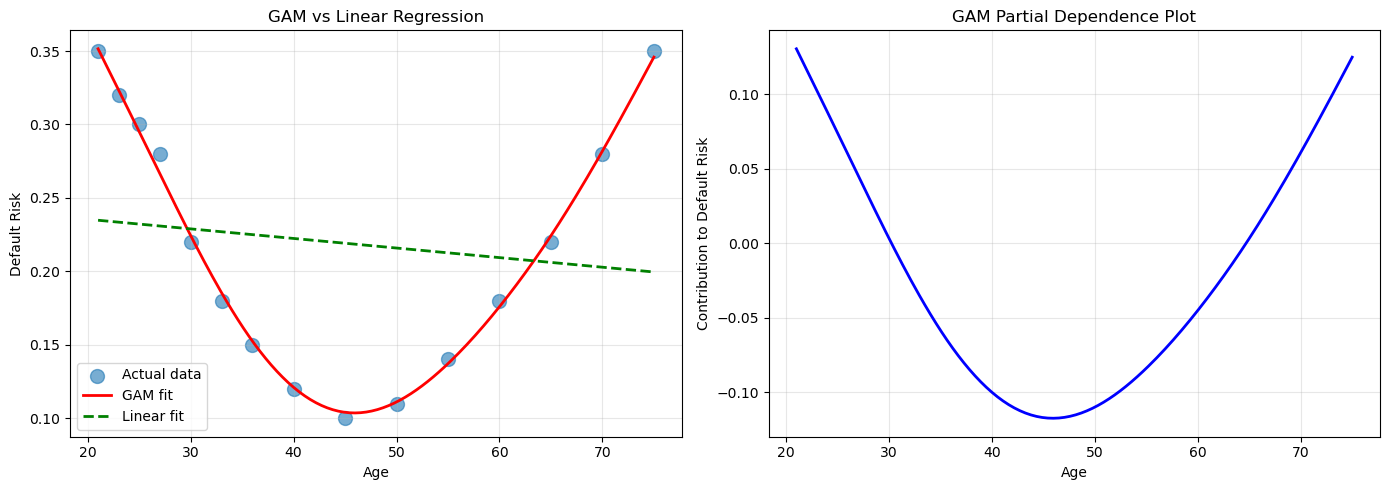


MODEL COMPARISON
Linear Regression - R²: 0.0177, MSE: 0.0071
GAM Model         - R²: 0.9967, MSE: 0.0000


: 

In [ ]:
# Visualize GAM results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scatter plot with GAM curve and Linear Regression curve
X_range = np.linspace(x.iloc[:, 0].min(), x.iloc[:, 0].max(), 200).reshape(-1, 1)
y_gam_pred = gam.predict(X_range)
y_linear_pred = model.predict(X_range)

axes[0].scatter(x, y, alpha=0.6, s=100, label='Actual data')
axes[0].plot(X_range, y_gam_pred, 'r-', linewidth=2, label='GAM fit')
axes[0].plot(X_range, y_linear_pred, 'g--', linewidth=2, label='Linear fit')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Default Risk')
axes[0].set_title('GAM vs Linear Regression')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Partial dependence (contribution of Age to Default Risk)
XX = np.linspace(x.iloc[:, 0].min(), x.iloc[:, 0].max(), 200).reshape(-1, 1)
pdep = gam.partial_dependence(0, X=XX)

axes[1].plot(XX, pdep, 'b-', linewidth=2)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Contribution to Default Risk')
axes[1].set_title('GAM Partial Dependence Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate prediction error
gam_pred = gam.predict(x)
gam_mse = np.mean((y - gam_pred) ** 2)
gam_r2 = 1 - (np.sum((y - gam_pred) ** 2) / np.sum((y - y.mean()) ** 2))

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(f"Linear Regression - R²: {r2:.4f}, MSE: {mse:.4f}")
print(f"GAM Model         - R²: {gam_r2:.4f}, MSE: {gam_mse:.4f}")
print("="*60)


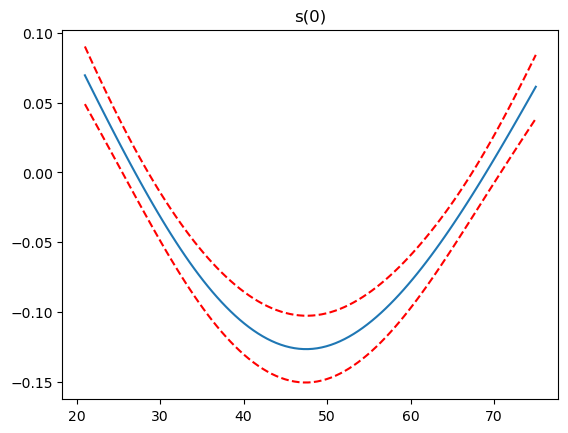

In [59]:
for i, term in enumerate(gam.terms):
    if term.isintercept:
        continue

    XX = gam.generate_X_grid(term=i)
    pdep, confi = gam.partial_dependence(term=i, X=XX, width=0.95)

    plt.figure()
    plt.plot(XX[:, term.feature], pdep)
    plt.plot(XX[:, term.feature], confi, c="r", ls="--")
    plt.title(repr(term))
    plt.show()